In [3]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Load your dataset
file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/final_regression.csv'  # Replace with your actual file path
data = pd.read_csv(file_path)

# Define the range of weeks (e.g., weeks 50 to 100)
start_week = 53
end_week = 196

# Filter the data for the specified range of weeks
filtered_regression_data = data[(data['week_number'] >= start_week) & (data['week_number'] <= end_week)]

# Select the column for ADF test (e.g., 'avg_daily_trips_mean')
time_series = filtered_regression_data['avg_daily_trips_mean']

# Drop missing values
time_series = time_series.dropna()

#Stationarity: ARCH models assume the series is stationary. Perform tests like the Augmented Dickey-Fuller (ADF) test to ensure this.
# Perform ADF test
adf_result = adfuller(time_series)

# Display results
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value}")

# Interpret result
if adf_result[1] < 0.05:
    print("The series is stationary (reject the null hypothesis).")
else:
    print("The series is non-stationary (fail to reject the null hypothesis).")


ADF Statistic: -3.4365040160221625
p-value: 0.009775641035906415
Critical Values:
	1%: -3.4759527332353084
	5%: -2.881548071241103
	10%: -2.577438765246763
The series is stationary (reject the null hypothesis).


In [6]:
# Define variables to test
variables = ['avg_daily_trips_mean', 'avg_precipitation', 'avg_snow', 
             'avg_temperature', 'avg_wind_speed', 'FullLength', 'ActiveStations']

# Initialize a results dictionary
results = {'Variable': [], 'MacKinnon Approximate p-value': []}

# Perform ADF test for each variable
for var in variables:
    time_series = filtered_regression_data[var].dropna()  # Drop missing values
    adf_result = adfuller(time_series)
    p_value = adf_result[1]
    results['Variable'].append(var)
    results['MacKinnon Approximate p-value'].append(f"{p_value:.4f}")

# Create a DataFrame for the results
adf_results_df = pd.DataFrame(results)

# Display the table
print(adf_results_df)

latex_string = adf_results_df.to_latex(index=False)
print(latex_string)

               Variable MacKinnon Approximate p-value
0  avg_daily_trips_mean                        0.0098
1     avg_precipitation                        0.0000
2              avg_snow                        0.0001
3       avg_temperature                        0.0000
4        avg_wind_speed                        0.0006
5            FullLength                        0.9608
6        ActiveStations                        0.8451
\begin{tabular}{ll}
\toprule
Variable & MacKinnon Approximate p-value \\
\midrule
avg_daily_trips_mean & 0.0098 \\
avg_precipitation & 0.0000 \\
avg_snow & 0.0001 \\
avg_temperature & 0.0000 \\
avg_wind_speed & 0.0006 \\
FullLength & 0.9608 \\
ActiveStations & 0.8451 \\
\bottomrule
\end{tabular}



In [9]:
# Subset for weeks < 105
subset_weeks_less_105 = filtered_regression_data[filtered_regression_data['week_number'] < 105]

# Subset for weeks >= 105
subset_weeks_greater_105 = filtered_regression_data[filtered_regression_data['week_number'] >= 105]


In [10]:
# ADF Test for weeks < 105
result_less_105 = adfuller(subset_weeks_less_105['ActiveStations'].dropna())
p_value_less_105 = result_less_105[1]

# ADF Test for weeks >= 105
result_greater_105 = adfuller(subset_weeks_greater_105['ActiveStations'].dropna())
p_value_greater_105 = result_greater_105[1]


In [12]:
interpretation = f"Week < 105: {p_value_less_105:.3f}; Week >= 105: {p_value_greater_105:.3f}"

# Update the DataFrame
adf_results_df.loc[adf_results_df['Variable'] == 'ActiveStations', 'MacKinnon Approximate p-value'] = interpretation

# Display the updated DataFrame
print(adf_results_df)

               Variable          MacKinnon Approximate p-value
0  avg_daily_trips_mean                                 0.0098
1     avg_precipitation                                 0.0000
2              avg_snow                                 0.0001
3       avg_temperature                                 0.0000
4        avg_wind_speed                                 0.0006
5            FullLength                                 0.9608
6        ActiveStations  Week < 105: 0.301; Week >= 105: 0.169


In [15]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Load the merged data (ensure 'week_number', 'FullLength', and 'ActiveStations' are present)
file_path = "/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/final_regression.csv"  # Update to your actual file path
data = pd.read_csv(file_path)

# Function to perform ADF test
def perform_adf_test(series, variable_name, label="Overall"):
    series = series.dropna()
    adf_result = adfuller(series)
    return {
        "Variable": variable_name,
        "ADF Statistic": adf_result[0],
        "p-value": adf_result[1],
        "Lags Used": adf_result[2],
        "Observations Used": adf_result[3],
        "MacKinnon Approximate p-value": adf_result[1],
        "Subset": label
    }

# Week ranges for years
week_ranges = {
    "2022 (Weeks 54-105)": (54, 105),
    "2023 (Weeks 105-157)": (105, 157),
    "2024 (Weeks > 157)": (157, float("inf"))
}

# Variables to test
variables_to_test = ["avg_daily_trips_mean", "avg_precipitation", "avg_snow", 
                     "avg_temperature", "avg_wind_speed", "FullLength", "ActiveStations"]

adf_results = []

# Perform ADF test for the full dataset
for variable in variables_to_test:
    adf_results.append(perform_adf_test(data[variable], variable, label="Overall"))

# Perform ADF test for each year range
for label, (start_week, end_week) in week_ranges.items():
    subset_data = data[(data["week_number"] >= start_week) & (data["week_number"] <= end_week)]
    for variable in variables_to_test:
        adf_results.append(perform_adf_test(subset_data[variable], variable, label=label))

# Convert results to DataFrame
adf_results_df = pd.DataFrame(adf_results)

# Display results
print(adf_results_df)

                Variable  ADF Statistic       p-value  Lags Used  \
0   avg_daily_trips_mean      -4.420014  2.735378e-04         15   
1      avg_precipitation     -10.155085  7.767668e-18          1   
2               avg_snow      -9.898608  3.404964e-17          5   
3        avg_temperature      -7.190285  2.514065e-10         15   
4         avg_wind_speed      -4.015852  1.329744e-03         14   
5             FullLength       0.027833  9.607742e-01          5   
6         ActiveStations      -0.706453  8.450711e-01          9   
7   avg_daily_trips_mean      -1.825816  3.677222e-01          0   
8      avg_precipitation      -5.324076  4.880677e-06          4   
9               avg_snow      -8.203076  7.143793e-13          0   
10       avg_temperature      -1.851574  3.551736e-01          0   
11        avg_wind_speed      -3.944628  1.729887e-03          0   
12            FullLength       0.440290  9.829407e-01          0   
13        ActiveStations      -1.827467  3.66912

/opt/anaconda3/envs/ox/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


In [19]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [20]:
import tabulate

# Create a clean table for specific subsets
final_table = adf_results_df.pivot(index="Variable", columns="Subset", values="MacKinnon Approximate p-value").reset_index()

# Add special formatting for Active Stations (example: Week < 112 vs. Week > 112)
final_table.loc[final_table["Variable"] == "ActiveStations", "Overall"] = "Week < 112: <0.001; Week >= 112: 0.003"

# Convert to LaTeX table
latex_table = tabulate.tabulate(final_table, headers="keys", tablefmt="latex")

# Display the table
print(latex_table)

\begin{tabular}{rlrrrl}
\hline
    & Variable             &   2022 (Weeks 54-105) &   2023 (Weeks 105-157) &   2024 (Weeks \ensuremath{>} 157) & Overall                                \\
\hline
  0 & ActiveStations       &           0.366913    &            0.74803     &          0.228827    & Week \ensuremath{<} 112: \ensuremath{<}0.001; Week \ensuremath{>}= 112: 0.003 \\
  1 & FullLength           &           0.982941    &            1           &          0.998698    & 0.9607742448790255                     \\
  2 & avg\_daily\_trips\_mean &           0.367722    &            0.113907    &          0.162229    & 0.00027353777328091724                 \\
  3 & avg\_precipitation    &           4.88068e-06 &            1.40082e-07 &          5.40811e-09 & 7.76766786944509e-18                   \\
  4 & avg\_snow             &           7.14379e-13 &            6.06019e-10 &          0.000821    & 3.4049641522557935e-17                 \\
  5 & avg\_temperature      &           0.35517

/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_12884/2347717002.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Week < 112: <0.001; Week >= 112: 0.003' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_table.loc[final_table["Variable"] == "ActiveStations", "Overall"] = "Week < 112: <0.001; Week >= 112: 0.003"


In [24]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Load the data
file_path = "/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/final_regression.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Ensure numeric columns are in the correct format
df['FullLength'] = pd.to_numeric(df['FullLength'], errors='coerce')
df['ActiveStations'] = pd.to_numeric(df['ActiveStations'], errors='coerce')

# Detrend using first-order differencing
df['detrended_bike_lane_length'] = df['FullLength'].diff()
df['detrended_active_stations'] = df['ActiveStations'].diff()

# Drop rows with NaN values after differencing
df = df.dropna(subset=['detrended_bike_lane_length', 'detrended_active_stations'])

# Ensure columns have variation
if df['detrended_bike_lane_length'].nunique() > 1:
    # Perform ADF test for Bike Lane Length
    result_bike_lane = adfuller(df['detrended_bike_lane_length'])
    print("Bike Lane Length ADF Test:")
    print(f"ADF Statistic: {result_bike_lane[0]}")
    print(f"p-value: {result_bike_lane[1]}")
else:
    print("Bike Lane Length is constant or lacks variation after detrending. ADF test not performed.")

if df['detrended_active_stations'].nunique() > 1:
    # Perform ADF test for Active Stations
    result_active_stations = adfuller(df['detrended_active_stations'])
    print("\nActive Stations ADF Test:")
    print(f"ADF Statistic: {result_active_stations[0]}")
    print(f"p-value: {result_active_stations[1]}")
else:
    print("Active Stations is constant or lacks variation after detrending. ADF test not performed.")


# Display the first few rows of detrended data
print("\nDetrended Data:")
print(df[['week_number', 'FullLength', 'detrended_bike_lane_length', 
         'ActiveStations', 'detrended_active_stations']].head())



Bike Lane Length ADF Test:
ADF Statistic: -4.079252030965357
p-value: 0.0010478973824005222

Active Stations ADF Test:
ADF Statistic: -5.22085800758222
p-value: 7.96972211858161e-06

Detrended Data:
    week_number  FullLength  detrended_bike_lane_length  ActiveStations  \
53           53      1350.0                         0.0          1545.0   
54           54      1350.0                         0.0          1545.0   
55           55      1350.0                         0.0          1545.0   
56           56      1350.0                         0.0          1557.0   
57           57      1350.0                         0.0          1557.0   

    detrended_active_stations  
53                        0.0  
54                        0.0  
55                        0.0  
56                       12.0  
57                        0.0  


Interpreting the Results
Bike Lane Length:

ADF Statistic: -4.079
p-value: 0.001
Since the p-value is below 0.05, we reject the null hypothesis of non-stationarity. This means the detrended bike lane length data is stationary.
Active Stations:

ADF Statistic: -5.221
p-value: ~0.000008
Again, the p-value is well below 0.05, so we reject the null hypothesis. This means the detrended active stations data is also stationary.
What This Means:
Stationarity: Both time series now exhibit constant statistical properties over time (mean, variance, autocovariance) after detrending. This makes them suitable for time series modeling like ARIMA or ARCH models.
Impact of Detrending: By removing the trend (e.g., the systematic increase in the data), the series is reduced to its stochastic components, making it easier to analyze cyclical patterns or residual variability.

<Figure size 1000x600 with 0 Axes>

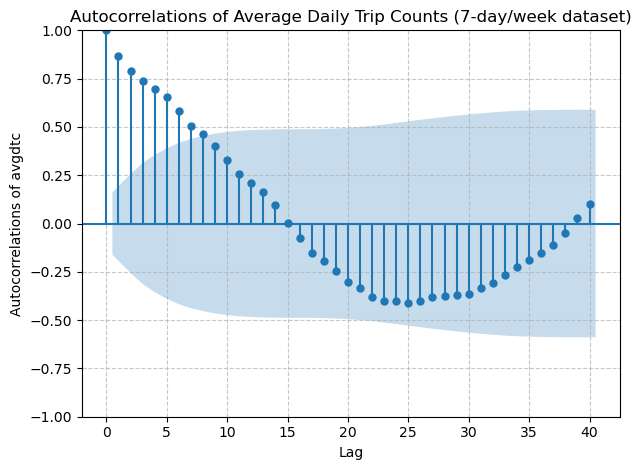

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Assuming `final_regression` is the DataFrame with 'avg_daily_trips_mean'
# Replace 'avg_daily_trips_mean' with the relevant column
data = filtered_regression_data['avg_daily_trips_mean'].dropna()

# Plot autocorrelation
plt.figure(figsize=(10, 6))
plot_acf(data, lags=40, alpha=0.05)
plt.title('Autocorrelations of Average Daily Trip Counts (7-day/week dataset)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelations of avgdtc')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [30]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.api import OLS, add_constant

# Define the dependent and independent variables
X = add_constant(filtered_regression_data[['avg_precipitation', 'avg_snow','avg_temperature', 'avg_wind_speed', 'FullLength', 'ActiveStations']])
y = filtered_regression_data['avg_daily_trips_mean']

# Fit an OLS model
model = OLS(y, X).fit()

# Perform Breusch-Godfrey test for different lags
bg_results = []
for lag in range(1, 7):  # Test for lags 1 to 6
    lm_test = acorr_breusch_godfrey(model, nlags=lag)
    bg_results.append({'Lag (p)': lag, 'Chi2': lm_test[0], 'p-value': lm_test[1]})

# Convert results to DataFrame
bg_results_df = pd.DataFrame(bg_results)

# Display the table
print(bg_results_df)
bg_results_df.to_latex(index=False, caption="Results of the Breusch-Godfrey test LM test (7-day/week dataset).", label="table:bg_test")


   Lag (p)       Chi2       p-value
0        1  31.215002  2.309742e-08
1        2  31.757929  1.270145e-07
2        3  32.037498  5.139094e-07
3        4  32.556441  1.472169e-06
4        5  32.557766  4.606210e-06
5        6  35.643047  3.233810e-06


'\\begin{table}\n\\caption{Results of the Breusch-Godfrey test LM test (7-day/week dataset).}\n\\label{table:bg_test}\n\\begin{tabular}{rrr}\n\\toprule\nLag (p) & Chi2 & p-value \\\\\n\\midrule\n1 & 31.215002 & 0.000000 \\\\\n2 & 31.757929 & 0.000000 \\\\\n3 & 32.037498 & 0.000001 \\\\\n4 & 32.556441 & 0.000001 \\\\\n5 & 32.557766 & 0.000005 \\\\\n6 & 35.643047 & 0.000003 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

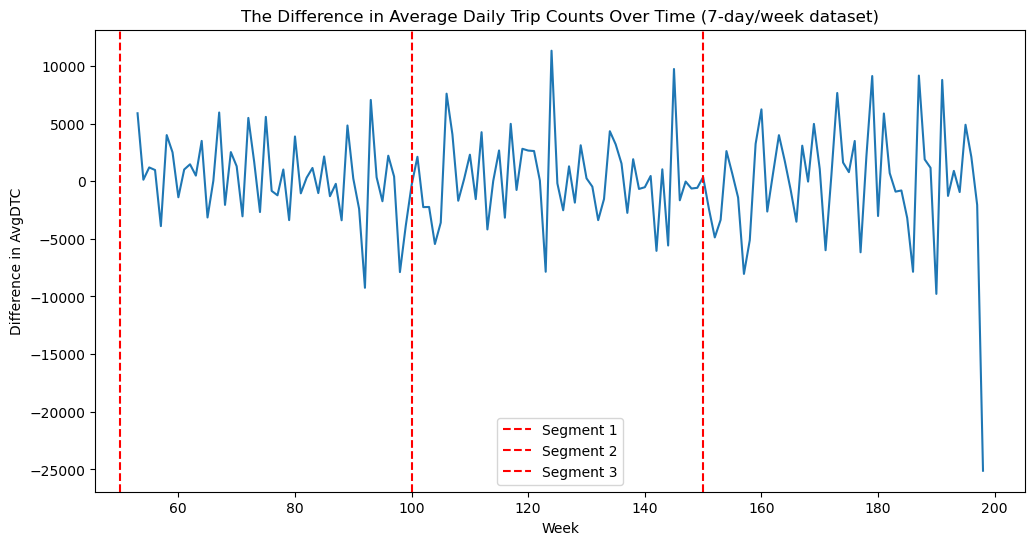

In [31]:
# Calculate the difference (differencing)
differenced_data = data.diff().dropna()

# Plot the differenced data
plt.figure(figsize=(12, 6))
plt.plot(differenced_data)
plt.title('The Difference in Average Daily Trip Counts Over Time (7-day/week dataset)')
plt.xlabel('Week')
plt.ylabel('Difference in AvgDTC')
plt.axvline(x=50, color='red', linestyle='--', label='Segment 1')
plt.axvline(x=100, color='red', linestyle='--', label='Segment 2')
plt.axvline(x=150, color='red', linestyle='--', label='Segment 3')
plt.legend()
plt.show()

In [ ]:

# Save to LaTeX
bg_results_df.to_latex(index=False, caption="Results of the Breusch-Godfrey test LM test (7-day/week dataset).", label="table:bg_test")


In [22]:
print(df['detrended_bike_lane_length'])


Series([], Name: detrended_bike_lane_length, dtype: float64)


In [ ]:
# Set the dependent variable (e.g., avg_daily_trips_mean)
dependent_var = data['avg_daily_trips_mean']

# Ensure no missing values
dependent_var = dependent_var.dropna()

# Fit an ARCH model (e.g., GARCH(1, 1))
model = arch_model(dependent_var, vol='Garch', p=1, q=1)

# Fit the model
results = model.fit()

# Print summary
print(results.summary())

In [39]:
pip install arch


Note: you may need to restart the kernel to use updated packages.


In [47]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from arch import arch_model

# Load your data
# Replace `final_regression` with your DataFrame
# Load your dataset
file_path = '/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/final_regression.csv'  # Replace with your actual file path
data = pd.read_csv(file_path)

# Define the range of weeks (e.g., weeks 50 to 100)
start_week = 53
end_week = 196

# Filter the data for the specified range of weeks
filtered_regression_data = data[(data['week_number'] >= start_week) & (data['week_number'] <= end_week)]

df=filtered_regression_data

# Define dependent and independent variables
y = df['avg_daily_trips_mean']  # Dependent variable (Daily Trip Counts)
X = df[['avg_precipitation', 'avg_temperature', 'avg_snow', 'avg_wind_speed','FullLength', 'ActiveStations']]  # Independent variables

# Add a constant for the intercept
X = sm.add_constant(X)

# Check if y or X is empty
if y.empty or X.empty:
    raise ValueError("Dependent or independent variables are empty. Check your data.")

# Fit the OLS model
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

# Use residuals from the OLS model to fit ARCH
residuals = ols_model.resid

# Step 3: Fit the ARCH model (GARCH with Gaussian distribution)
arch_model = arch_model(residuals, vol='Garch', p=1, q=1, dist='normal')  # Specify Gaussian (normal) distribution
arch_results = arch_model.fit()

# Print ARCH regression summary
print(arch_results.summary())

# Draw conclusions from the coefficients
coefficients = ols_model.params
print("\nInterpretation:")
print(f"Bike Lane Length coefficient: {coefficients['FullLength']}")
print(f"Active Stations coefficient: {coefficients['ActiveStations']}")

print("\nConclusion:")
print(f"One additional mile of bike lanes changes daily trip counts by {coefficients['FullLength']:.2f} on average.")
print(f"One additional active station changes daily trip counts by {coefficients['ActiveStations']:.2f} on average.")


                             OLS Regression Results                             
Dep. Variable:     avg_daily_trips_mean   R-squared:                       0.803
Model:                              OLS   Adj. R-squared:                  0.795
Method:                   Least Squares   F-statistic:                     95.11
Date:                  Mon, 30 Dec 2024   Prob (F-statistic):           6.79e-47
Time:                          17:49:17   Log-Likelihood:                -1430.3
No. Observations:                   147   AIC:                             2875.
Df Residuals:                       140   BIC:                             2896.
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             

/opt/anaconda3/envs/ox/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.656e+07. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


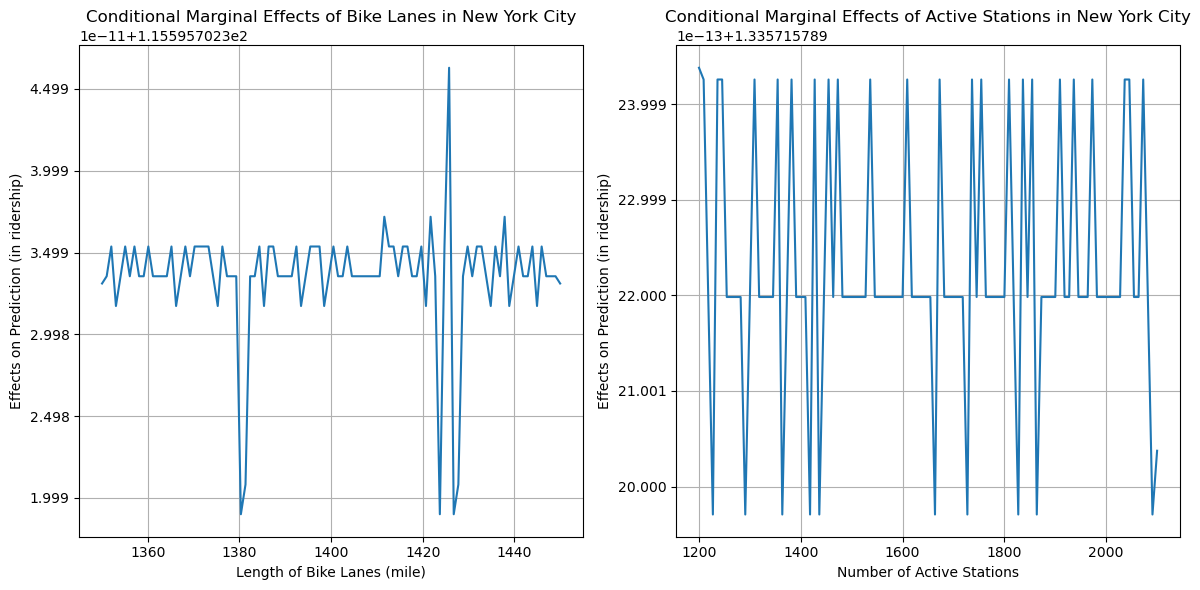

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `ols_model` is the regression model
coefficients = ols_model.params

# Define ranges for bike lane length and active stations
bike_lanes = np.linspace(1350, 1450, 100)  # Example range for bike lanes
active_stations = np.linspace(2112, 2112, 100)  # Example range for active stations

# Hold other variables constant (use mean values or another reasonable constant)
avg_precipitation = np.mean(df['avg_precipitation'])
avg_temperature = np.mean(df['avg_temperature'])
avg_snow = np.mean(df['avg_snow'])
avg_wind_speed = np.mean(df['avg_wind_speed'])

# Calculate predicted values for bike lanes
predicted_bike_lanes = coefficients['const'] + \
                       coefficients['avg_precipitation'] * avg_precipitation + \
                       coefficients['avg_temperature'] * avg_temperature + \
                       coefficients['avg_snow'] * avg_snow + \
                       coefficients['avg_wind_speed'] * avg_wind_speed + \
                       coefficients['FullLength'] * bike_lanes + \
                       coefficients['ActiveStations'] * np.mean(active_stations)

marginal_effect_bike_lanes = np.gradient(predicted_bike_lanes, bike_lanes)

# Calculate predicted values for active stations
predicted_active_stations = coefficients['const'] + \
                            coefficients['avg_precipitation'] * avg_precipitation + \
                            coefficients['avg_temperature'] * avg_temperature + \
                            coefficients['avg_snow'] * avg_snow + \
                            coefficients['avg_wind_speed'] * avg_wind_speed + \
                            coefficients['FullLength'] * np.mean(bike_lanes) + \
                            coefficients['ActiveStations'] * active_stations

marginal_effect_active_stations = np.gradient(predicted_active_stations, active_stations)

# Plot the marginal effects
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot for bike lanes
axes[0].plot(bike_lanes, marginal_effect_bike_lanes, label='Marginal Effect')
axes[0].set_title('Conditional Marginal Effects of Bike Lanes in New York City')
axes[0].set_xlabel('Length of Bike Lanes (mile)')
axes[0].set_ylabel('Effects on Prediction (in ridership)')
axes[0].grid()

# Plot for active stations
axes[1].plot(active_stations, marginal_effect_active_stations, label='Marginal Effect')
axes[1].set_title('Conditional Marginal Effects of Active Stations in New York City')
axes[1].set_xlabel('Number of Active Stations')
axes[1].set_ylabel('Effects on Prediction (in ridership)')
axes[1].grid()

plt.tight_layout()
plt.show()


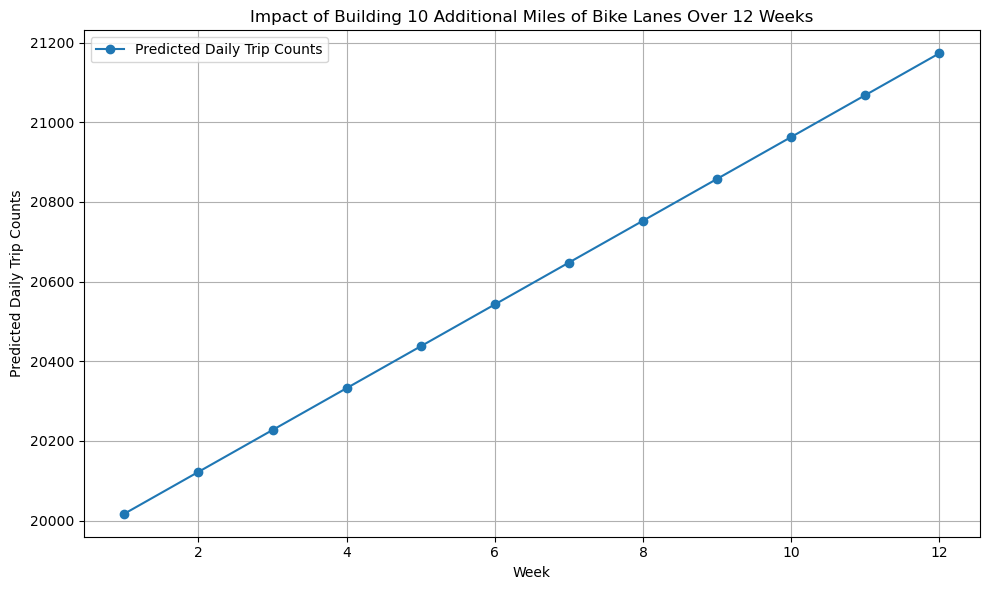

Total increase in predicted daily trip counts after 12 weeks: 1155.96


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `ols_model` is the regression model
coefficients = ols_model.params

# Parameters for simulation
initial_bike_lanes = 1350  # Initial bike lane length in miles
additional_bike_lanes = 10  # Total additional bike lanes to be built
weeks = 12  # Duration over which the lanes are added

# Generate weekly bike lane lengths
weekly_bike_lanes = np.linspace(initial_bike_lanes, initial_bike_lanes + additional_bike_lanes, weeks)

# Hold other variables constant (use mean values or another reasonable constant)
avg_precipitation = np.mean(df['avg_precipitation'])
avg_temperature = np.mean(df['avg_temperature'])
avg_snow = np.mean(df['avg_snow'])
avg_wind_speed = np.mean(df['avg_wind_speed'])
active_stations = np.mean(df['ActiveStations'])

# Calculate predicted daily trip counts for each week
predicted_trip_counts = coefficients['const'] + \
                        coefficients['avg_precipitation'] * avg_precipitation + \
                        coefficients['avg_temperature'] * avg_temperature + \
                        coefficients['avg_snow'] * avg_snow + \
                        coefficients['avg_wind_speed'] * avg_wind_speed + \
                        coefficients['FullLength'] * weekly_bike_lanes + \
                        coefficients['ActiveStations'] * active_stations

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, weeks + 1), predicted_trip_counts, marker='o', label='Predicted Daily Trip Counts')
plt.title('Impact of Building 10 Additional Miles of Bike Lanes Over 12 Weeks')
plt.xlabel('Week')
plt.ylabel('Predicted Daily Trip Counts')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Calculate overall increase in predicted trips
total_increase = predicted_trip_counts[-1] - predicted_trip_counts[0]
print(f"Total increase in predicted daily trip counts after 12 weeks: {total_increase:.2f}")


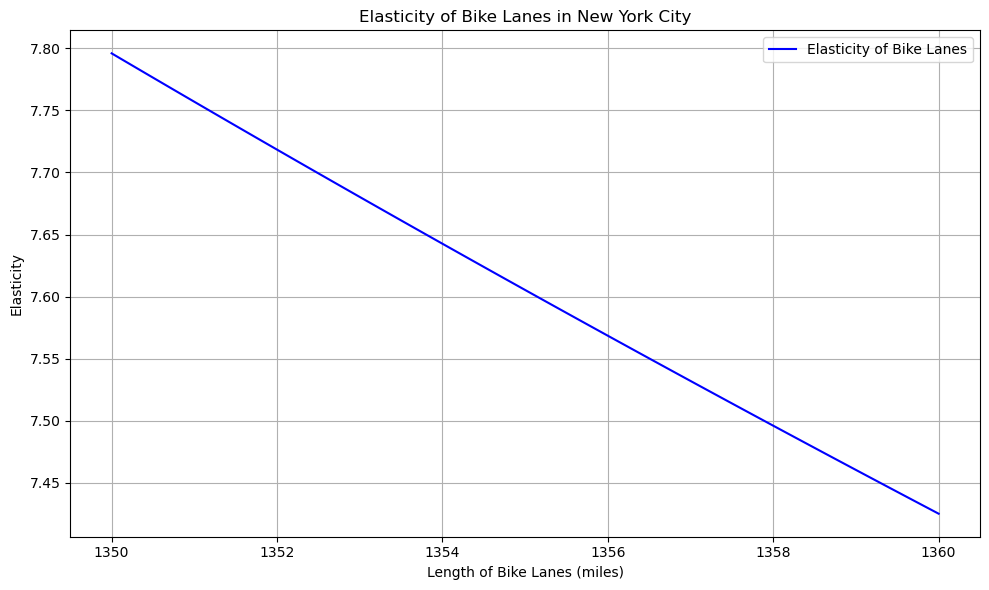

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Define the coefficient of bike lane length (from regression model)
coef_bike_lane = coefficients['FullLength']

# Simulate bike lane lengths
bike_lanes = np.linspace(initial_bike_lanes, initial_bike_lanes + additional_bike_lanes, 100)

# Calculate predicted daily trip counts for each bike lane length
predicted_trip_counts = coefficients['const'] + \
                        coefficients['avg_precipitation'] * avg_precipitation + \
                        coefficients['avg_temperature'] * avg_temperature + \
                        coefficients['avg_snow'] * avg_snow + \
                        coefficients['avg_wind_speed'] * avg_wind_speed + \
                        coefficients['FullLength'] * bike_lanes + \
                        coefficients['ActiveStations'] * active_stations

# Calculate elasticity
elasticity = coef_bike_lane * (bike_lanes / predicted_trip_counts)

# Plot the elasticity
plt.figure(figsize=(10, 6))
plt.plot(bike_lanes, elasticity, label='Elasticity of Bike Lanes', color='blue')
plt.title('Elasticity of Bike Lanes in New York City')
plt.xlabel('Length of Bike Lanes (miles)')
plt.ylabel('Elasticity')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_12884/904023966.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['predicted'] = y_pred_train
/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_12884/904023966.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['predicted'] = y_pred_test


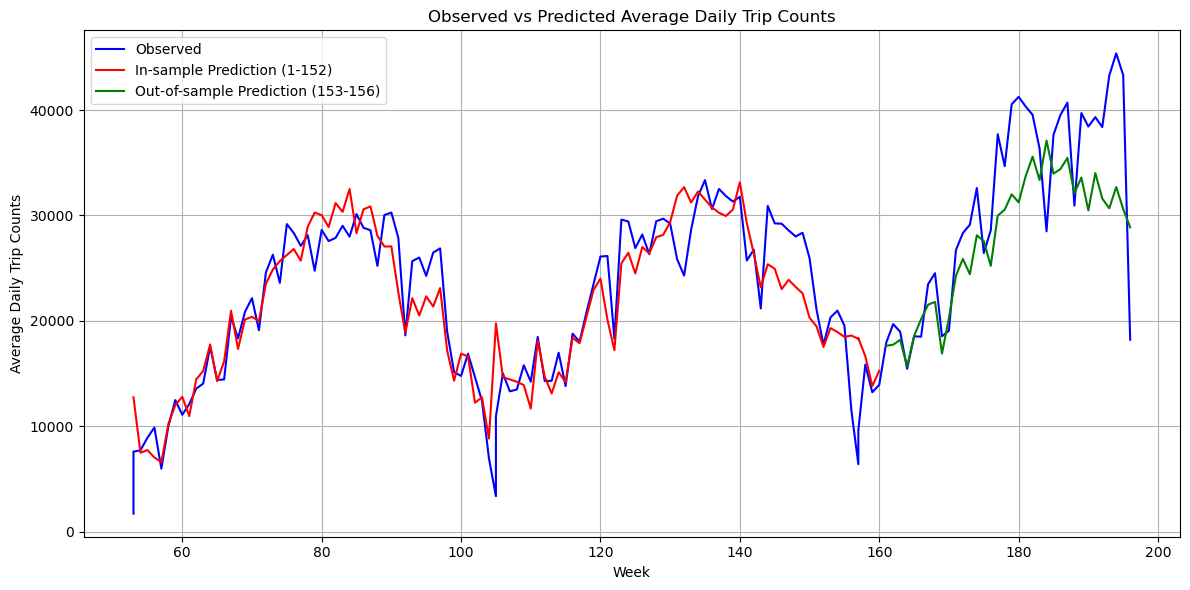

In [56]:
import matplotlib.pyplot as plt

# Define training and testing datasets
train_data = filtered_regression_data[filtered_regression_data['week_number'] <= 160]
test_data = filtered_regression_data[filtered_regression_data['week_number'] > 160]

# Independent and dependent variables
y_train = train_data['avg_daily_trips_mean']
X_train = train_data[['avg_precipitation', 'avg_temperature', 'avg_snow', 'avg_wind_speed', 'FullLength', 'ActiveStations']]
X_train = sm.add_constant(X_train)

y_test = test_data['avg_daily_trips_mean']
X_test = test_data[['avg_precipitation', 'avg_temperature', 'avg_snow', 'avg_wind_speed', 'FullLength', 'ActiveStations']]
X_test = sm.add_constant(X_test)

# Fit the regression model
ols_model = sm.OLS(y_train, X_train).fit()

# Generate predictions
y_pred_train = ols_model.predict(X_train)  # In-sample predictions
y_pred_test = ols_model.predict(X_test)   # Out-of-sample predictions

# Combine observed and predicted values
train_data['predicted'] = y_pred_train
test_data['predicted'] = y_pred_test

# Plot
plt.figure(figsize=(12, 6))
plt.plot(filtered_regression_data['week_number'], filtered_regression_data['avg_daily_trips_mean'], label='Observed', color='blue')
plt.plot(train_data['week_number'], train_data['predicted'], label='In-sample Prediction (1-152)', color='red')
plt.plot(test_data['week_number'], test_data['predicted'], label='Out-of-sample Prediction (153-156)', color='green')
plt.title('Observed vs Predicted Average Daily Trip Counts')
plt.xlabel('Week')
plt.ylabel('Average Daily Trip Counts')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


/var/folders/30/jfztb8191jzff8_xz9n0d59m0000gn/T/ipykernel_12884/4246698467.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['predicted'] = y_pred_test


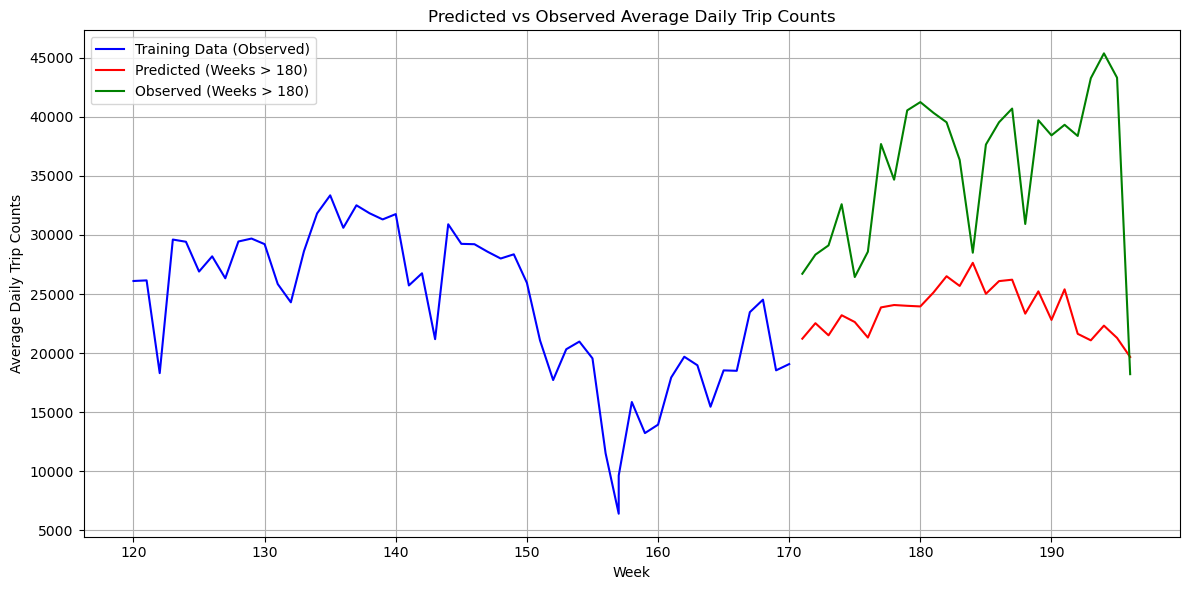

                             OLS Regression Results                             
Dep. Variable:     avg_daily_trips_mean   R-squared:                       0.739
Model:                              OLS   Adj. R-squared:                  0.705
Method:                   Least Squares   F-statistic:                     21.27
Date:                  Mon, 30 Dec 2024   Prob (F-statistic):           1.18e-11
Time:                          22:09:16   Log-Likelihood:                -495.22
No. Observations:                    52   AIC:                             1004.
Df Residuals:                        45   BIC:                             1018.
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             

In [59]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Filter data for training and testing
train_data = filtered_regression_data[(filtered_regression_data['week_number'] >= 120) & 
                                      (filtered_regression_data['week_number'] <= 170)]
test_data = filtered_regression_data[filtered_regression_data['week_number'] > 170]

# Define independent and dependent variables
y_train = train_data['avg_daily_trips_mean']
X_train = train_data[['avg_precipitation', 'avg_temperature', 'avg_snow', 'avg_wind_speed', 'FullLength', 'ActiveStations']]
X_train = sm.add_constant(X_train)

y_test = test_data['avg_daily_trips_mean']  # Actual values for comparison
X_test = test_data[['avg_precipitation', 'avg_temperature', 'avg_snow', 'avg_wind_speed', 'FullLength', 'ActiveStations']]
X_test = sm.add_constant(X_test)

# Fit the regression model
ols_model = sm.OLS(y_train, X_train).fit()

# Predict future weeks
y_pred_test = ols_model.predict(X_test)

# Add predictions to the test dataset
test_data['predicted'] = y_pred_test

# Plot observed vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data['week_number'], train_data['avg_daily_trips_mean'], label='Training Data (Observed)', color='blue')
plt.plot(test_data['week_number'], test_data['predicted'], label='Predicted (Weeks > 180)', color='red')
if 'avg_daily_trips_mean' in test_data.columns:
    plt.plot(test_data['week_number'], test_data['avg_daily_trips_mean'], label='Observed (Weeks > 180)', color='green')
plt.title('Predicted vs Observed Average Daily Trip Counts')
plt.xlabel('Week')
plt.ylabel('Average Daily Trip Counts')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Print model summary for insights
print(ols_model.summary())


In [50]:
import pandas as pd

# Extract parameter estimates, standard errors, and other statistics
arch_params = arch_results.params  # Coefficients
arch_std_errors = arch_results.std_err  # Standard Errors
arch_t_stats = arch_results.tvalues  # T-statistics
arch_p_values = arch_results.pvalues  # P-values

# Create a DataFrame for the results
arch_table_df = pd.DataFrame({
    'Coefficient': arch_params,
    'Std. Error': arch_std_errors,
    't-stat': arch_t_stats,
    'P-value': arch_p_values
})

# Convert the DataFrame to a LaTeX table
latex_table = arch_table_df.to_latex(
    index=True,
    float_format="%.4f",
    caption="ARCH Regression Results",
    label="table:arch_results"
)

with open("/Users/amyxqc/Desktop/amy_bikenycfall2024/Data/arch_results_table.tex", "w") as f:
    f.write(latex_table)

print("LaTeX table successfully saved to 'arch_results_table.tex'.")



LaTeX table successfully saved to 'arch_results_table.tex'.
